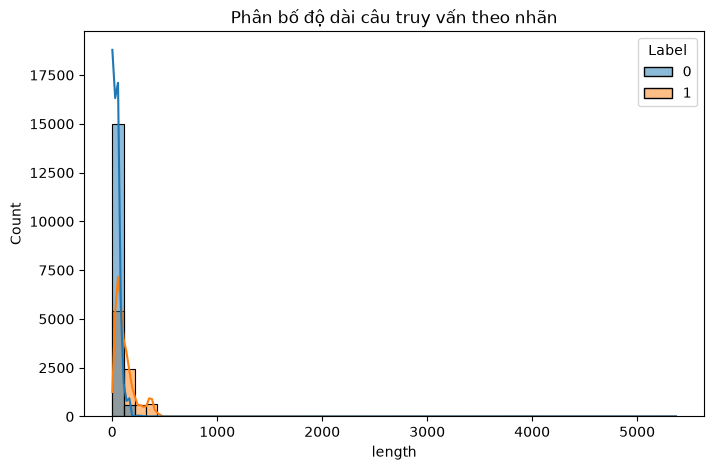

       kw_UNION     kw_OR   kw_DROP  kw_SELECT     kw_--
Label                                                   
0      0.028549  0.263027  0.002753   0.670465  0.000128
1      0.212371  0.391782  0.003406   0.878269  0.349154


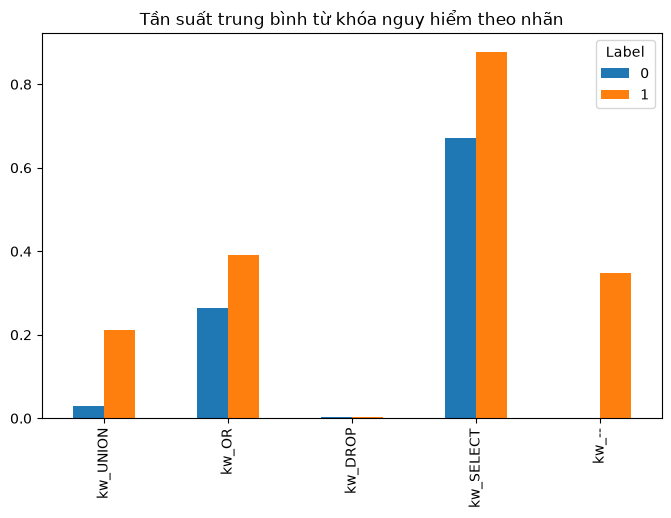

         char_'    char_;    char_=   char_--
Label                                        
0      0.661503  0.032198  0.208872  0.000128
1      1.128433  0.007251  1.205669  0.349154


In [3]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("../datasets/processed/train.csv")

train_df['length'] = train_df['Query'].str.len()

plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x='length', hue='Label', bins=50, kde=True)
plt.title("Phân bố độ dài câu truy vấn theo nhãn")
plt.savefig("../docs/images/length_distribution.png")
plt.show()

dangerous_keywords = ['UNION', 'OR', 'DROP', 'SELECT', '--']

def keyword_count(query, kw):
    return len(re.findall(re.escape(kw), query, flags=re.IGNORECASE))

for kw in dangerous_keywords:
    train_df[f'kw_{kw}'] = train_df['Query'].apply(lambda q: keyword_count(q, kw))

kw_summary = train_df.groupby('Label')[[f'kw_{kw}' for kw in dangerous_keywords]].mean()
print(kw_summary)

kw_summary.T.plot(kind='bar', figsize=(8,5))
plt.title("Tần suất trung bình từ khóa nguy hiểm theo nhãn")
plt.savefig("../docs/images/keyword_frequency.png")
plt.show()

special_chars = ["'", ";", "=", "--"]
for ch in special_chars:
    train_df[f'char_{ch}'] = train_df['Query'].apply(lambda q: q.count(ch))

char_summary = train_df.groupby('Label')[[f'char_{ch}' for ch in special_chars]].mean()
print(char_summary)

In [ ]:
import re

simple_chars = {
    'char_comma': ',',
    'char_lparen': '(',
    'char_rparen': ')',
    'char_percent': '%',
}
for name, ch in simple_chars.items():
    train_df[name] = train_df['Query'].apply(lambda q: q.count(ch))

# Comment markers -- gộp cả 3 loại (--, #, /* */) thành 1 cột tổng hợp
def count_comment_markers(query):
    return (
        len(re.findall(r'--', query)) +
        query.count('#') +
        len(re.findall(r'/\*', query))
    )
train_df['n_comment_markers'] = train_df['Query'].apply(count_comment_markers)

# Thống kê trung bình theo nhãn
extra_char_cols = list(simple_chars.keys()) + ['n_comment_markers']
extra_char_summary = train_df.groupby('Label')[extra_char_cols].mean()
print(extra_char_summary)

# Tỷ lệ chênh lệch lớp 1 / lớp 0, để xem đặc trưng nào đáng giữ
ratio = extra_char_summary.loc[1] / (extra_char_summary.loc[0] + 1e-6)
print("\nTỷ lệ chênh lệch (lớp 1 / lớp 0):\n", ratio.sort_values(ascending=False))

       char_comma  char_lparen  char_rparen  char_percent  n_comment_markers
Label                                                                       
0        0.335424     0.291704     0.286135      0.030022           0.000640
1        1.808723     3.539991     3.988904      0.196770           0.525599

Tỷ lệ chênh lệch (lớp 1 / lớp 0):
 n_comment_markers    819.809691
char_rparen           13.940589
char_lparen           12.135517
char_percent           6.554025
char_comma             5.392327
dtype: float64


In [5]:
train_df['uppercase_ratio'] = train_df['Query'].apply(
    lambda q: sum(1 for c in q if c.isupper()) / max(len(q), 1)
)
train_df['n_whitespace'] = train_df['Query'].apply(lambda q: q.count(' '))
train_df['n_digit'] = train_df['Query'].apply(lambda q: sum(c.isdigit() for c in q))

structure_cols = ['uppercase_ratio', 'n_whitespace', 'n_digit']
structure_summary = train_df.groupby('Label')[structure_cols].mean()
print(structure_summary)

       uppercase_ratio  n_whitespace    n_digit
Label                                          
0             0.237200      6.537895   1.707464
1             0.003855     43.993078  18.320589


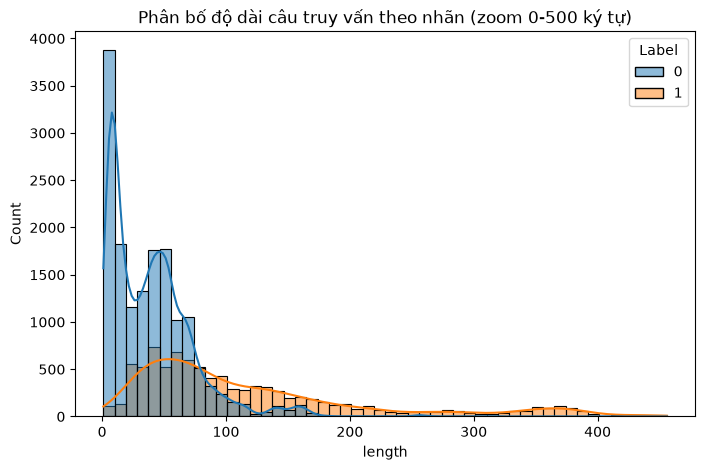

         count        mean        std  min   25%   50%    75%     max
Label                                                                
0      15622.0   39.894508  54.977360  1.0  11.0  35.0   55.0  5370.0
1       9102.0  118.736981  96.652344  1.0  51.0  86.0  151.0   456.0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=train_df[train_df['length'] <= 500], x='length', hue='Label', bins=50, kde=True)
plt.title("Phân bố độ dài câu truy vấn theo nhãn (zoom 0-500 ký tự)")
plt.savefig("../docs/images/length_distribution_zoom.png")
plt.show()

print(train_df.groupby('Label')['length'].describe())